# 2. Impurity Mixture Effects

## 2.1 Problem statement

Adding even small amounts of helium or water vapour to the sCO₂ stream
**eliminates the single critical point** and replaces it with a *phase
envelope*: a dew-point and bubble-point curve that bound a two-phase
coexistence region. Operating points that were safely supercritical for
pure CO₂ may sit inside this envelope for the mixture.

For TMSR / HTGR coupling, helium ingress from the intermediate loop is
plausible (the secondary side runs helium-cooled in some designs), and the
shifted phase envelope must be detected before the cycle is committed to
those operating conditions.

## 2.2 Mathematical description

The Helmholtz-energy mixture model in CoolProp uses the GERG-2008 / HEOS
formulation. For a binary CO₂–He mixture at composition $x_{\rm He}$:

$$
\alpha^{r}_{\rm mix}(T, \rho, \vec{x}) \;=\;
\sum_i x_i \alpha^{r}_i(T, \rho) \;+\; \Delta\alpha^{r}(\vec{x})
$$

where $\Delta\alpha^{r}$ is a binary departure function.
The phase envelope is found by solving the equal-fugacity condition
$\hat{f}_i^L = \hat{f}_i^V$ at constant $T$ and varying $P$.

## 2.3 Code implementation — phase-state guard

In [1]:
import sys
from pathlib import Path

_repo_root = next(
    p for p in [Path.cwd(), *Path.cwd().resolve().parents]
    if (p / "pyproject.toml").exists()
)
sys.path.insert(0, str(_repo_root / "src"))

from sco2_mixture_validation import calc_mixture_properties

# Compressor-inlet-like point: 35 °C, 8 MPa
result = calc_mixture_properties(T=308.15, P=8.0e6, x_he=0.0, verbose=False)
print(f"Pure CO2: rho = {result.rho_pure:.2f} kg/m³, Cp = {result.cp_pure:.0f} J/kg·K")

# 1% He impurity
result = calc_mixture_properties(T=308.15, P=8.0e6, x_he=0.01, verbose=False)
if result is None:
    print("Mixture in two-phase region — engineering must avoid this point")
else:
    print(f"1% He : rho = {result.rho_mix:.2f} kg/m³ "
          f"(Δ {result.rho_delta_pct:+.2f}% vs pure)")

Pure CO2: rho = 419.09 kg/m³, Cp = 29594 J/kg·K
1% He : rho = 311.54 kg/m³ (Δ -25.66% vs pure)


## 2.4 Numerical sweep — density vs He fraction

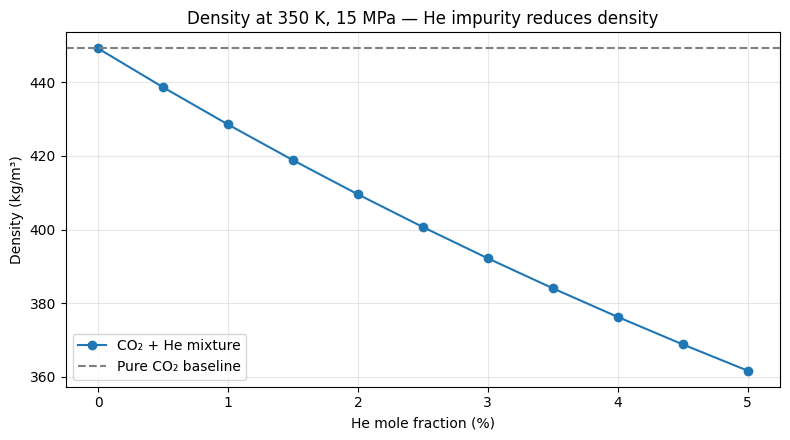

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x_he_arr = np.linspace(0.0, 0.05, 11)
rho_pure = []
rho_mix  = []
for x in x_he_arr:
    r = calc_mixture_properties(T=350.0, P=15.0e6, x_he=float(x), verbose=False)
    if r is None:
        rho_pure.append(np.nan); rho_mix.append(np.nan)
    else:
        rho_pure.append(r.rho_pure); rho_mix.append(r.rho_mix)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x_he_arr * 100, rho_mix, "o-", label="CO₂ + He mixture")
ax.axhline(rho_pure[0], color="grey", linestyle="--", label="Pure CO₂ baseline")
ax.set_xlabel("He mole fraction (%)")
ax.set_ylabel("Density (kg/m³)")
ax.set_title("Density at 350 K, 15 MPa — He impurity reduces density")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2.5 Engineering implication

- **He impurity lowers density** — compressor mass flow drops at fixed volume flow
- The phase envelope **shifts upward in pressure** at fixed temperature, so
  conditions that were single-phase for pure CO₂ may be two-phase for the mixture
- Always run the phase guard *before* using mixture properties in any
  cycle-balance calculation — silent two-phase calls degrade cycle
  efficiency predictions

## 2.6 Known limitations

- HEOS binary parameters for CO₂–He are based on relatively sparse data;
  uncertainty rises sharply above 5 % He
- Surface effects and mass-transfer kinetics within the cycle are *not*
  modelled — this is bulk thermodynamics only

## 2.7 References

- Kunz & Wagner (2012), *J. Chem. Eng. Data* — GERG-2008
- Span & Wagner (1996) — the pure-CO₂ EOS basis for the departure function